### 1. importation de jeu de données 

In [1]:
import pandas as pd

df = pd.read_csv('../data/city_lifestyle_dataset.csv')

In [2]:
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


### 2. Implementation de la methode UMAP

In [3]:
# Features numériques
features = ['population_density', 'avg_income', 'internet_penetration', 'air_quality_index', 
            'public_transport_score', 'green_space_ratio', 'happiness_score', 'avg_rent'] 

X = df[features].copy()

#print("Shape des données:", X.shape)
#print(X.head()) 

In [5]:
import numpy as np
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler


# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP en 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='euclidean')
embedding = reducer.fit_transform(X_scaled)




c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Visualsation

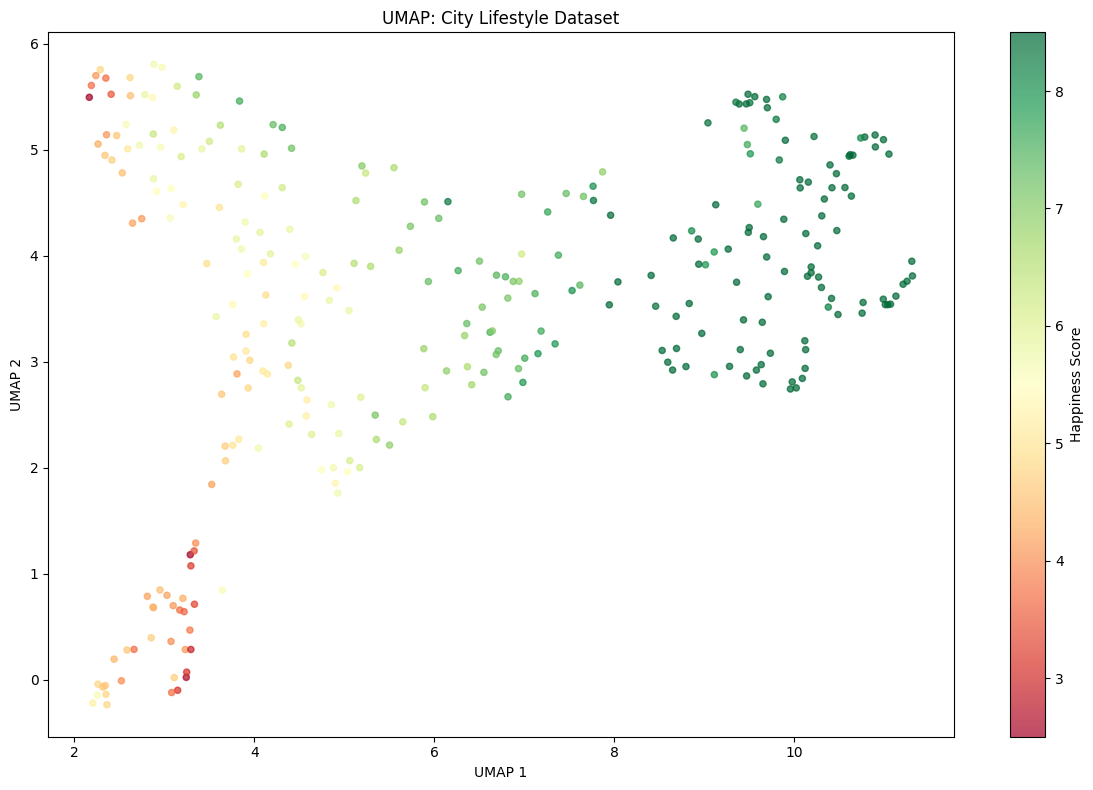

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

colors = X['happiness_score']
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, cmap='RdYlGn', s=20, alpha=0.7)
plt.colorbar(scatter, label='Happiness Score')
plt.title('UMAP: City Lifestyle Dataset')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show() 



### 2. Observation sur la structure UMAP :
La projection UMAP révèle une séparation claire en clusters corrélés au happiness score : 
* Les villes à haut bonheur (vert, >6) forment un groupe compact à droite, indiquant des similarités en qualité de vie, espaces verts et transport
* tandis que les villes à faible bonheur (rouge, <4) se dispersent à gauche, liées à haute densité, loyer et pollution. 

-> Trois sous-clusters intermédiaires (jaune/vert clair) suggèrent des transitions (ex. villes riches mais polluées). Cette structure locale préservée met en évidence des profils lifestyle distincts (éco-heureux vs urbain-stressant).
